# Penguin Species Classification



Dataset Source
https://github.com/allisonhorst/palmerpenguins/blob/main/README.md

!pip install xgboost lightgbm catboost

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import joblib

In [3]:
df = pd.read_csv("../data/penguins_lter.csv")

print(df.shape)
display(df.head())

(344, 17)


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [4]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [5]:
df["studyName"].value_counts()

studyName
PAL0910    120
PAL0809    114
PAL0708    110
Name: count, dtype: int64

In [6]:
column_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "unique_values": df.nunique(dropna=False),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values(["missing_percent", "unique_values"], ascending=[False, True])

display(column_summary)

,dtype,unique_values,missing_count,missing_percent
Comments,object,8,318,92.44
Delta 15 N (o/oo),float64,331,14,4.07
Delta 13 C (o/oo),float64,332,13,3.78
Sex,object,4,10,2.91
Flipper Length (mm),float64,56,2,0.58
Culmen Depth (mm),float64,81,2,0.58
Body Mass (g),float64,95,2,0.58
Culmen Length (mm),float64,165,2,0.58
Region,object,1,0,0.00
Stage,object,1,0,0.00


In [8]:
categorical_check_cols = [
    "Species", "Region", "Island", "Stage",
    "Clutch Completion", "Sex", "studyName", "Comments"
]

for col in categorical_check_cols:
    print("\n" + "="*70)
    print(f"Value counts for: {col}")
    print(df[col].value_counts(dropna=False))


Value counts for: Species
Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64

Value counts for: Region
Region
Anvers    344
Name: count, dtype: int64

Value counts for: Island
Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Value counts for: Stage
Stage
Adult, 1 Egg Stage    344
Name: count, dtype: int64

Value counts for: Clutch Completion
Clutch Completion
Yes    308
No      36
Name: count, dtype: int64

Value counts for: Sex
Sex
MALE      168
FEMALE    165
NaN        10
.           1
Name: count, dtype: int64

Value counts for: studyName
studyName
PAL0910    120
PAL0809    114
PAL0708    110
Name: count, dtype: int64

Value counts for: Comments
Comments
NaN                                                                     318
Nest never observed with full clutch.                                    13
Not enough bloo

In [9]:
df["has_comment"] = df["Comments"].notna().astype(int)

print(df["has_comment"].value_counts())

has_comment
0    318
1     26
Name: count, dtype: int64


In [10]:
df = df.drop(columns=["Comments"])

In [11]:
# Clean Sex
df["Sex"] = df["Sex"].replace(".", np.nan)
df["Sex"] = df["Sex"].fillna("Unknown")

print(df["Sex"].value_counts(dropna=False))

Sex
MALE       168
FEMALE     165
Unknown     11
Name: count, dtype: int64


In [12]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'has_comment'],
      dtype='object')

In [13]:
df = df.rename(columns={
    "studyName": "study_name",
    "Species": "species",
    "Island": "island",
    "Clutch Completion": "clutch_completion",
    "Date Egg": "date_egg",
    "Culmen Length (mm)": "culmen_length_mm",
    "Culmen Depth (mm)": "culmen_depth_mm",
    "Flipper Length (mm)": "flipper_length_mm",
    "Body Mass (g)": "body_mass_g",
    "Sex": "sex",
    "Delta 15 N (o/oo)": "delta_15_n",
    "Delta 13 C (o/oo)": "delta_13_c"
})

In [14]:
species_map = {
    "Adelie Penguin (Pygoscelis adeliae)": "Adelie",
    "Gentoo penguin (Pygoscelis papua)": "Gentoo",
    "Chinstrap penguin (Pygoscelis antarctica)": "Chinstrap"
}

df["species"] = df["species"].map(species_map)

print(df["species"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [15]:
cols_to_drop = [
    "Sample Number",
    "Region",
    "Stage",
    "Individual ID",
    "date_egg",
    "study_name"
]

df = df.drop(columns=cols_to_drop)

print("Shape after dropping weak columns:", df.shape)
display(df.head())

Shape after dropping weak columns: (344, 11)


,species,island,clutch_completion,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,delta_15_n,delta_13_c,has_comment
0,Adelie,Torgersen,Yes,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,1
1,Adelie,Torgersen,Yes,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,0
2,Adelie,Torgersen,Yes,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,0
3,Adelie,Torgersen,Yes,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,1
4,Adelie,Torgersen,Yes,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,0


In [16]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_percent
delta_15_n,14,4.07
delta_13_c,13,3.78
culmen_length_mm,2,0.58
culmen_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
species,0,0.00
island,0,0.00
clutch_completion,0,0.00
sex,0,0.00


In [17]:
target_col = "species"

feature_cols = [
    "island",
    "clutch_completion",
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex",
    "delta_15_n",
    "delta_13_c",
    "has_comment"
]

df_model = df[feature_cols + [target_col]].copy()

print("Model dataframe shape:", df_model.shape)
display(df_model.head())

Model dataframe shape: (344, 11)


,island,clutch_completion,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,delta_15_n,delta_13_c,has_comment,species
0,Torgersen,Yes,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,1,Adelie
1,Torgersen,Yes,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,0,Adelie
2,Torgersen,Yes,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,0,Adelie
3,Torgersen,Yes,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,1,Adelie
4,Torgersen,Yes,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,0,Adelie


In [18]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (240, 10) (240,)
Validation shape: (52, 10) (52,)
Test shape: (52, 10) (52,)


In [20]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Target classes:", label_encoder.classes_)

Target classes: ['Adelie' 'Chinstrap' 'Gentoo']


In [21]:
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "delta_15_n",
    "delta_13_c"
]

categorical_features = [
    "island",
    "clutch_completion",
    "sex",
    "has_comment"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'delta_15_n', 'delta_13_c']
Categorical features: ['island', 'clutch_completion', 'sex', 'has_comment']


In [22]:
skewness_before = X_train[numeric_features].skew(numeric_only=True).sort_values(key=np.abs, ascending=False)
print("Skewness before scaling:")
display(skewness_before.to_frame("skewness"))

Skewness before scaling:


,skewness
body_mass_g,0.417236
delta_13_c,0.333544
flipper_length_mm,0.320992
delta_15_n,0.298082
culmen_depth_mm,-0.147725
culmen_length_mm,0.084281


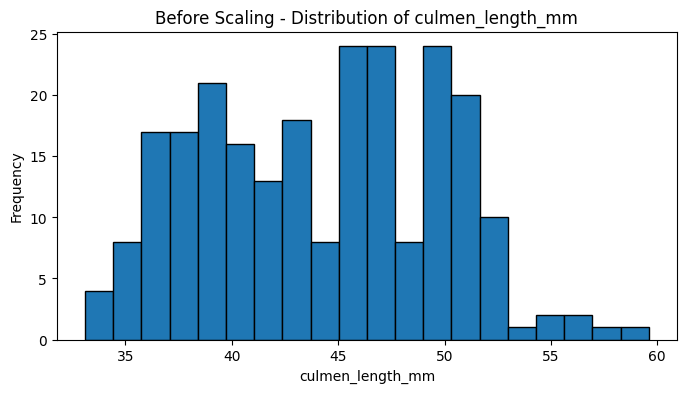

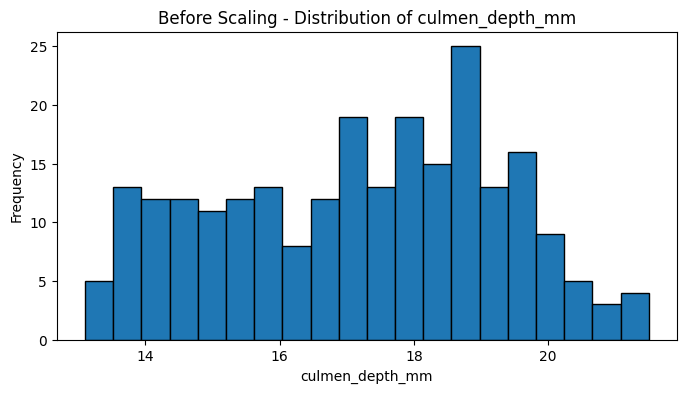

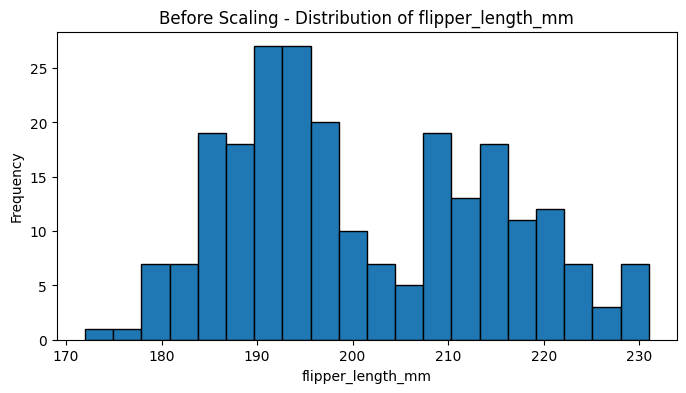

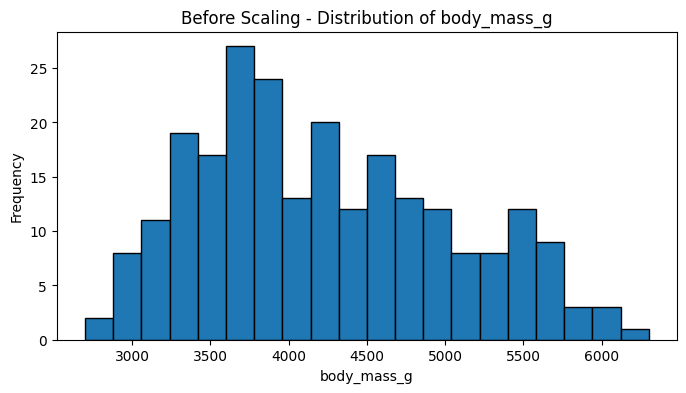

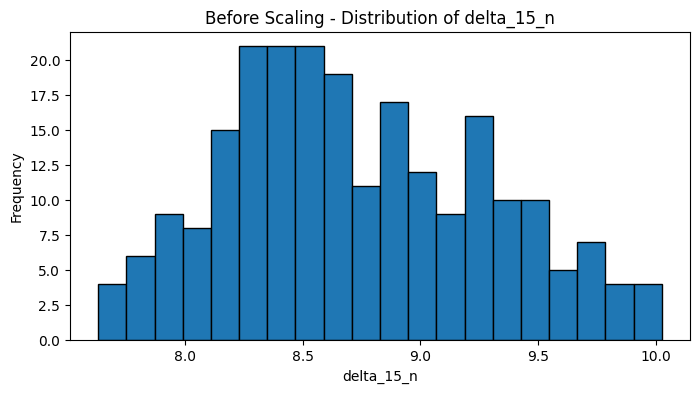

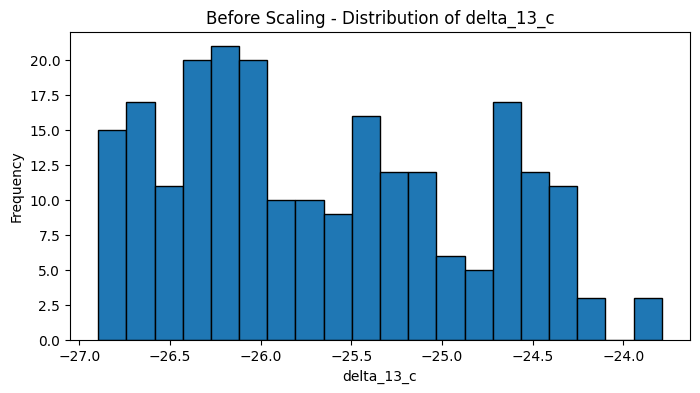

In [23]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    plt.hist(X_train[col].dropna(), bins=20, edgecolor="black")
    plt.title(f"Before Scaling - Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Use: 

median imputation for numeric missing values
constant / most-frequent imputation (mode) for categoricals
StandardScaler for numeric features
OneHotEncoder for categoricals

In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [25]:
numeric_transformer_for_plot = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_scaled_numeric = numeric_transformer_for_plot.fit_transform(X_train[numeric_features])

X_train_scaled_numeric = pd.DataFrame(
    X_train_scaled_numeric,
    columns=numeric_features,
    index=X_train.index
)

display(X_train_scaled_numeric.head())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,delta_15_n,delta_13_c
36,-0.966527,1.384787,-0.792705,-0.354641,0.859163,0.690051
19,0.337571,2.115652,-0.505861,-0.041492,0.723144,1.136248
260,-0.260140,-1.684848,0.498092,-0.354641,-1.068205,-1.185182
109,-0.169578,0.897543,-0.290728,0.678750,1.094505,0.270756
89,-0.948415,0.800095,-0.792705,-0.793049,-0.655313,-0.570329


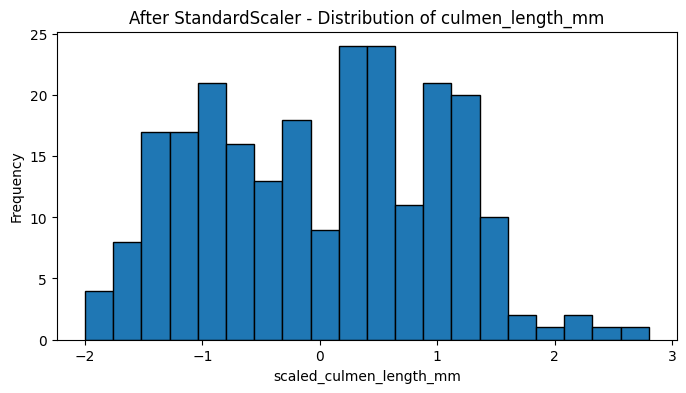

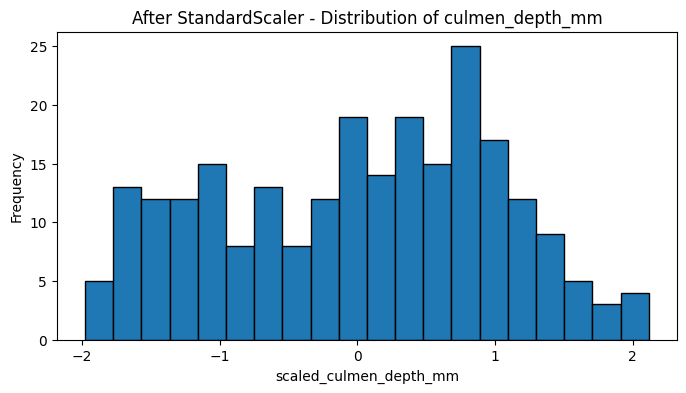

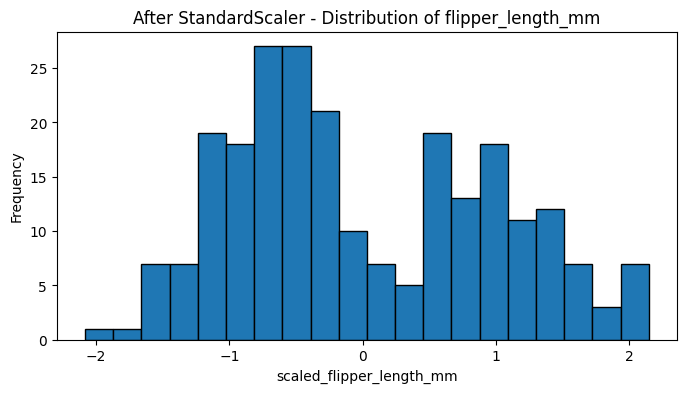

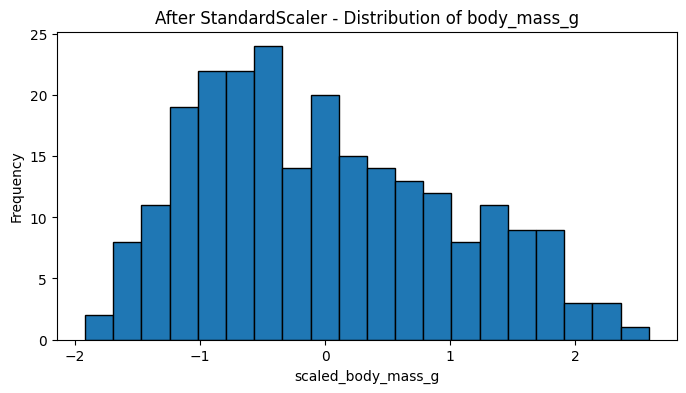

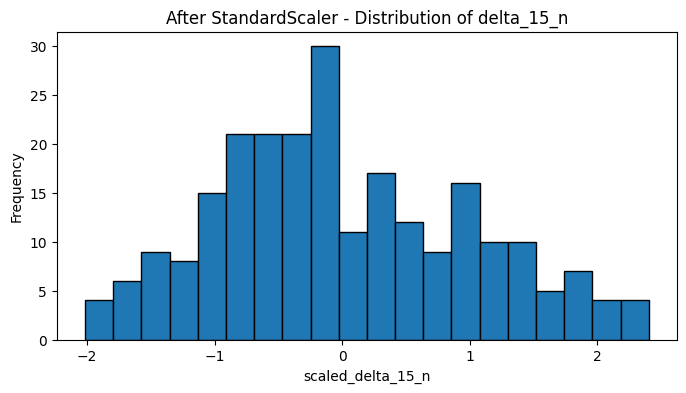

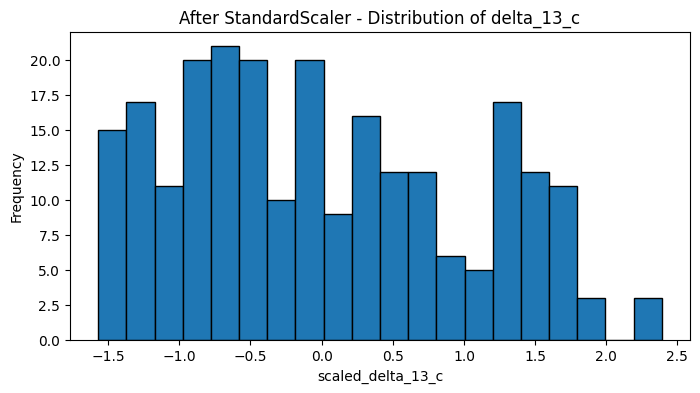

In [27]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    plt.hist(X_train_scaled_numeric[col], bins=20, edgecolor="black")
    plt.title(f"After StandardScaler - Distribution of {col}")
    plt.xlabel(f"scaled_{col}")
    plt.ylabel("Frequency")
    plt.show()

In [28]:
skewness_after = X_train_scaled_numeric.skew().sort_values(key=np.abs, ascending=False)
print("Skewness after scaling:")
display(skewness_after.to_frame("skewness"))

Skewness after scaling:


,skewness
body_mass_g,0.420111
delta_13_c,0.362209
delta_15_n,0.327658
flipper_length_mm,0.325052
culmen_depth_mm,-0.148898
culmen_length_mm,0.083621


In [29]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "decision_tree": DecisionTreeClassifier(
        random_state=42
    ),
    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "xgboost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        use_label_encoder=False
    ),
    "catboost": CatBoostClassifier(
        loss_function="MultiClass",
        verbose=0,
        random_state=42
    ),
    "lightgbm": LGBMClassifier(
        objective="multiclass",
        random_state=42,
        verbose=-1
    )
}

In [30]:
param_distributions = {
    "logistic_regression": {
        "model__C": np.logspace(-3, 2, 20),
        "model__solver": ["lbfgs", "saga"]
    },

    "decision_tree": {
        "model__criterion": ["gini", "entropy", "log_loss"],
        "model__max_depth": [None, 3, 5, 7, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10, 15],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__max_features": [None, "sqrt", "log2"]
    },

    "random_forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    },

    "gradient_boosting": {
        "model__n_estimators": [50, 100, 150, 200],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.8, 1.0],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "xgboost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__reg_lambda": [1, 3, 5]
    },

    "catboost": {
        "model__iterations": [100, 200, 300],
        "model__depth": [4, 6, 8, 10],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__l2_leaf_reg": [1, 3, 5, 7, 9]
    },

    "lightgbm": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [-1, 5, 10, 15],
        "model__min_child_samples": [5, 10, 20],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [31]:
def evaluate_classifier(model, X_data, y_true, label_encoder, dataset_name="Validation"):
    y_pred = model.predict(X_data)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")

    print(f"\n{'='*70}")
    print(f"{dataset_name} Metrics")
    print(f"{'='*70}")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 Macro      : {f1:.4f}")
    print(f"PrecisionMacro: {prec:.4f}")
    print(f"Recall Macro  : {rec:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    ))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.show()

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": prec,
        "recall_macro": rec
    }


##########################################################################################
Now tuning model: logistic_regression
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 1.0
Best params: {'model__solver': 'lbfgs', 'model__C': 2.636650898730358}

logistic_regression - Validation Metrics
Accuracy      : 1.0000
F1 Macro      : 1.0000
PrecisionMacro: 1.0000
Recall Macro  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52



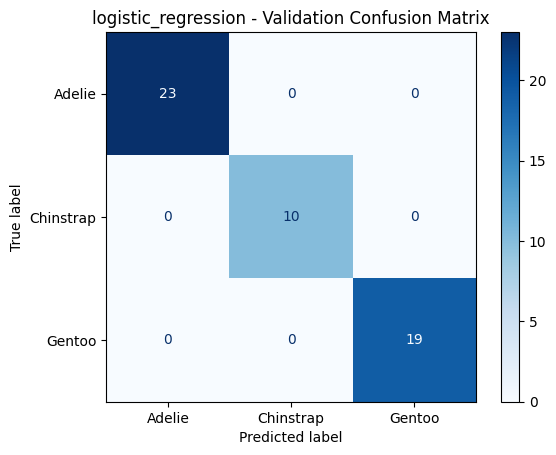


##########################################################################################
Now tuning model: decision_tree
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 0.9761864047944758
Best params: {'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None, 'model__criterion': 'log_loss'}

decision_tree - Validation Metrics
Accuracy      : 0.9615
F1 Macro      : 0.9676
PrecisionMacro: 0.9733
Recall Macro  : 0.9649

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.92      1.00      0.96        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      0.89      0.94        19

    accuracy                           0.96        52
   macro avg       0.97      0.96      0.97        52
weighted avg       0.96      0.96      0.96   

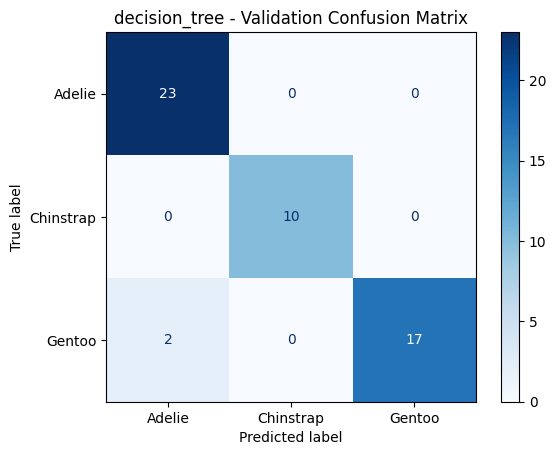


##########################################################################################
Now tuning model: random_forest
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 0.9897274243408841
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}

random_forest - Validation Metrics
Accuracy      : 0.9808
F1 Macro      : 0.9754
PrecisionMacro: 0.9861
Recall Macro  : 0.9667

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.96      1.00      0.98        23
   Chinstrap       1.00      0.90      0.95        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           0.98        52
   macro avg       0.99      0.97      0.98        52
weighted avg       0.98      0.98      0.98        5

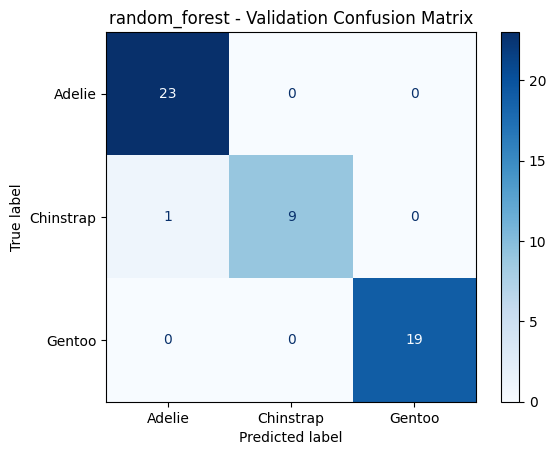


##########################################################################################
Now tuning model: gradient_boosting
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 0.9846682648141603
Best params: {'model__subsample': 0.8, 'model__n_estimators': 50, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.2}

gradient_boosting - Validation Metrics
Accuracy      : 0.9808
F1 Macro      : 0.9754
PrecisionMacro: 0.9861
Recall Macro  : 0.9667

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.96      1.00      0.98        23
   Chinstrap       1.00      0.90      0.95        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           0.98        52
   macro avg       0.99      0.97      0.98        52
weighted avg       0.98      0.98      0.98        52


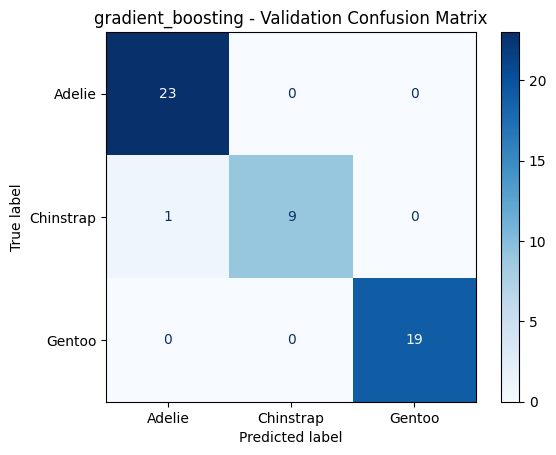


##########################################################################################
Now tuning model: xgboost
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 0.9846682648141603
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 3, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.7}

xgboost - Validation Metrics
Accuracy      : 1.0000
F1 Macro      : 1.0000
PrecisionMacro: 1.0000
Recall Macro  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg     

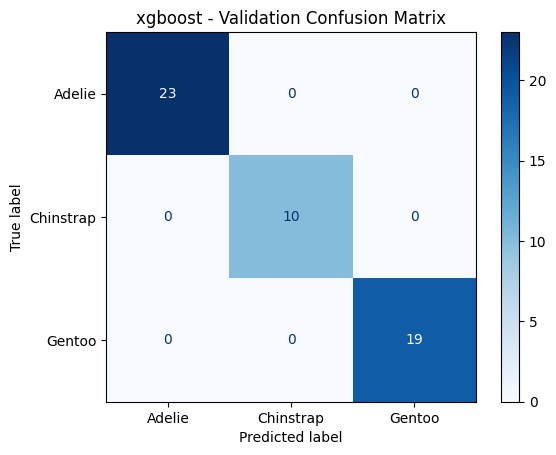


##########################################################################################
Now tuning model: catboost
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 0.9792897139031735
Best params: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 7, 'model__iterations': 300, 'model__depth': 10}

catboost - Validation Metrics
Accuracy      : 1.0000
F1 Macro      : 1.0000
PrecisionMacro: 1.0000
Recall Macro  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52



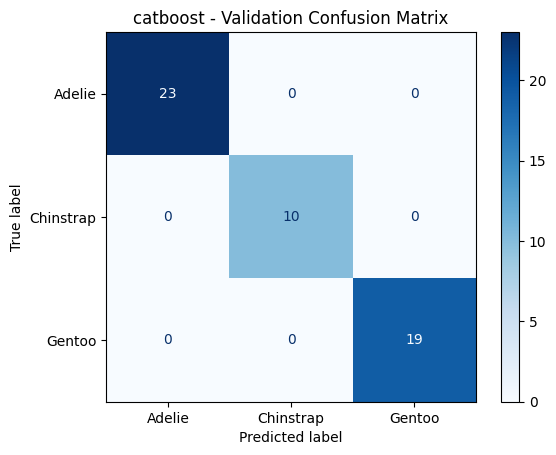


##########################################################################################
Now tuning model: lightgbm
##########################################################################################
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV score: 0.9846682648141603
Best params: {'model__subsample': 1.0, 'model__num_leaves': 31, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}

lightgbm - Validation Metrics
Accuracy      : 1.0000
F1 Macro      : 1.0000
PrecisionMacro: 1.0000
Recall Macro  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted av

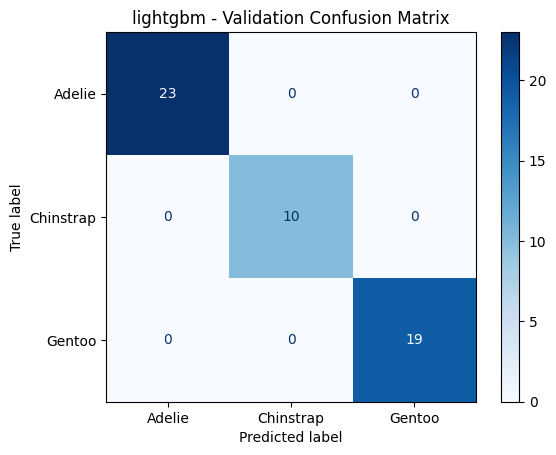

In [32]:
search_objects = {}
validation_results = []

os.makedirs("saved_models", exist_ok=True)

for model_name, model in models.items():
    print("\n" + "#"*90)
    print(f"Now tuning model: {model_name}")
    print("#"*90)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=20,
        scoring="f1_macro",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train_enc)

    print("\nBest CV score:", search.best_score_)
    print("Best params:", search.best_params_)

    search_objects[model_name] = search

    # Save tuned pipeline right away
    joblib.dump(search.best_estimator_, f"saved_models/{model_name}_tuned_pipeline.pkl")

    # Evaluate on validation set
    val_metrics = evaluate_classifier(
        model=search.best_estimator_,
        X_data=X_val,
        y_true=y_val_enc,
        label_encoder=label_encoder,
        dataset_name=f"{model_name} - Validation"
    )

    validation_results.append({
        "model": model_name,
        "best_cv_f1_macro": search.best_score_,
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_precision_macro": val_metrics["precision_macro"],
        "val_recall_macro": val_metrics["recall_macro"]
    })

In [33]:
validation_results_df = pd.DataFrame(validation_results).sort_values(
    by=["val_f1_macro", "val_accuracy"],
    ascending=False
)

display(validation_results_df)

,model,best_cv_f1_macro,val_accuracy,val_f1_macro,val_precision_macro,val_recall_macro
0,logistic_regression,1.000000,1.000000,1.000000,1.000000,1.000000
4,xgboost,0.984668,1.000000,1.000000,1.000000,1.000000
5,catboost,0.979290,1.000000,1.000000,1.000000,1.000000
6,lightgbm,0.984668,1.000000,1.000000,1.000000,1.000000
2,random_forest,0.989727,0.980769,0.975364,0.986111,0.966667
3,gradient_boosting,0.984668,0.980769,0.975364,0.986111,0.966667
1,decision_tree,0.976186,0.961538,0.967593,0.973333,0.964912


In [34]:
best_model_name = validation_results_df.iloc[0]["model"]
best_search = search_objects[best_model_name]

print("Best model based on validation set:", best_model_name)
print("Best validation row:")
display(validation_results_df.head(1))

Best model based on validation set: logistic_regression
Best validation row:


,model,best_cv_f1_macro,val_accuracy,val_f1_macro,val_precision_macro,val_recall_macro
0,logistic_regression,1.0,1.0,1.0,1.0,1.0


In [35]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val_enc = np.concatenate([y_train_enc, y_val_enc])

final_best_model = best_search.best_estimator_
final_best_model.fit(X_train_val, y_train_val_enc)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
joblib.dump(final_best_model, "saved_models/final_best_model.pkl")
joblib.dump(label_encoder, "saved_models/label_encoder.pkl")

print("Saved:")
print("- saved_models/final_best_model.pkl")
print("- saved_models/label_encoder.pkl")

Saved:
- saved_models/final_best_model.pkl
- saved_models/label_encoder.pkl



Final Best Model - Test Set Metrics
Accuracy      : 0.9808
F1 Macro      : 0.9834
PrecisionMacro: 0.9861
Recall Macro  : 0.9815

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.96      1.00      0.98        23
   Chinstrap       1.00      1.00      1.00        11
      Gentoo       1.00      0.94      0.97        18

    accuracy                           0.98        52
   macro avg       0.99      0.98      0.98        52
weighted avg       0.98      0.98      0.98        52



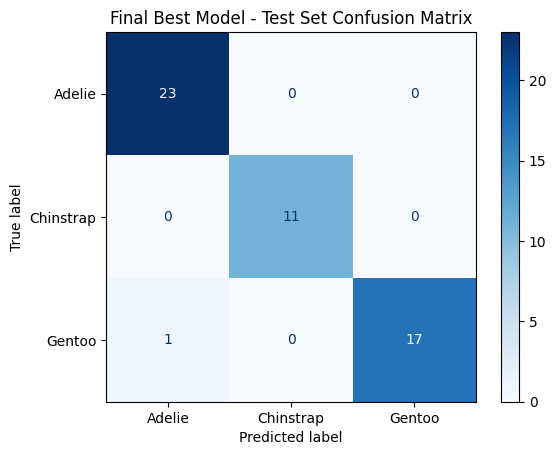

In [37]:
test_metrics = evaluate_classifier(
    model=final_best_model,
    X_data=X_test,
    y_true=y_test_enc,
    label_encoder=label_encoder,
    dataset_name="Final Best Model - Test Set"
)

In [38]:
preprocessor_fitted = final_best_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

print("Total transformed features:", len(feature_names))
print(feature_names[:50])

Total transformed features: 16
['num__culmen_length_mm' 'num__culmen_depth_mm' 'num__flipper_length_mm'
 'num__body_mass_g' 'num__delta_15_n' 'num__delta_13_c'
 'cat__island_Biscoe' 'cat__island_Dream' 'cat__island_Torgersen'
 'cat__clutch_completion_No' 'cat__clutch_completion_Yes'
 'cat__sex_FEMALE' 'cat__sex_MALE' 'cat__sex_Unknown' 'cat__has_comment_0'
 'cat__has_comment_1']
